## Construct and Preprocess BactHeCom DB

In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
# Paths
data_dir = "../data"
xlsx_file = f"{data_dir}/datos_BactHeCom_HUVR_v1.xlsx"
codes2names_file = f"{data_dir}/codes2names.csv"

In [3]:
df=pd.read_excel(xlsx_file, sheet_name='Hoja1', index_col=0)
df.head()

,fecha_ingreso,fecha_alta,duracion_hospitalizacion,fecha_nacimiento,edad,sexo,codigo_postal,mujer_gestante,infarto,insuficiencia_cardiaca,...,resultado_antibiograma_hemocultivo_R_CMI,resultado_antibiograma_hemocultivo_S,resultado_antibiograma_hemocultivo_S_CMI,resultado_antibiograma_hemocultivo_I,resultado_antibiograma_hemocultivo_I_CMI,IRAs_nosocomial,area_hosp,mortalidad,uci_por_el_episodio,duracion_UCI
record_id,,,,,,,,,,,,,,,,,,,,,
1,2021-08-24,2021-09-09,16,1943-03-28,78,Hombre,4007,0,0,0,...,">16 mg/L, >4 mg/L, >1 mg/L, >8 mg/L, >4/76 mg/...","Gentamicina, Amikacina, Aztreonam, Tobramicina...","<=2 mg/L, <=8 mg/L, 2 mg/L, <=2 mg/L, <=2 mg/L...","Ciprofloxacino, Levofloxacino, Ticarcilina, Pi...","<=0.06 mg/L, <=0.5 mg/L, 16 mg/L, 4 mg/L, <=1 ...",Si,UCI,1,1,14
2,2023-06-18,2023-07-13,25,1959-12-16,63,Mujer,4740,0,0,0,...,>4/76 mg/L,"Levofloxacino, Ampicilina/sulbactam, Imipenem,...","<=0.5 mg/L, <=8/4 mg/L, <=1 mg/L, <=1 mg/L, <=...","Cefuroxima, Ciprofloxacino","<=8 mg/L, 0.5 mg/L",Si,General,0,1,3
3,2022-02-11,2022-04-06,54,1976-11-14,45,Hombre,4700,0,0,0,...,">8 mg/L, <=1 mg/L, 4 mg/L, >32 mg/L, >16 mg/L,...","Ciprofloxacino, Trimetroprim/sulfametoxazol, C...","<=0.06 mg/L, <=2/38 mg/L, <=1 mg/L, <=8 mg/L, ...",Amikacina,<=8 mg/L,Si,UCI,0,1,24
4,2021-05-15,2021-07-28,74,1992-09-27,28,Hombre,18800,0,0,0,...,">32 mg/L, >8 mg/L, >16 mg/L, >16 mg/L, 16 mg/L...","Ceftazidima/avibactam, Colistina, Tobramicina,...","<=2 mg/L, <=2 mg/L, <=2 mg/L, <=1 mg/L",Meropenem,8 mg/L,Si,General,0,1,42
5,2021-07-04,2022-01-04,184,1994-07-13,26,Mujer,23009,0,0,0,...,">16 mg/L, >4 mg/L, >8 mg/L, >1 mg/L, >8 mg/L, ...","Ceftazidima/avibactam, Amikacina, Tobramicina,...","<=2 mg/L, <=8 mg/L, 0.25 mg/L, <=2 mg/L, 1.5 m...","Imipenem, Levofloxacino, Ceftazidima, Ciproflo...","2 mg/L, <=0.5 mg/L, 8 mg/L, <=0.06 mg/L",Si,General,0,1,78


In [4]:

df.columns.values

array(['fecha_ingreso', 'fecha_alta', 'duracion_hospitalizacion',
       'fecha_nacimiento', 'edad', 'sexo', 'codigo_postal',
       'mujer_gestante', 'infarto', 'insuficiencia_cardiaca', 'evp',
       'e_cerebrovascular', 'demencia', 'e_pulmonar_cronica',
       'ulcera_peptica', 'colagenopatia', 'hemiplejia', 'erc',
       'neoplasia_tratamiento_activo', 'neoplasia_solida_metastasica',
       'neoplasia_solida_no_metastasica', 'tipo_cancer', 'linfoma',
       'leucemia', 'sida', 'tipo_hepatopatia', 'diabetes',
       'diabetes_sin_lesion_organo_diana',
       'diabetes_con_lesion_organo_diana', 'inmunosupresion',
       'causa_inmunosupresion', 'TOS', 'TPH', 'clasificacion_quemadura',
       'gran_quemado', 'sepsis', 'shock_septico', 'hospit_ano_previo',
       'hospit_mes_previo', 'hospit_ano_previo_uci',
       'hemodialisis_permanente', 'dialisis_peritoneal', 'cateter_venoso',
       'sonda_urinaria', 'sonda_nasogastrica', 'derivacion_ventriculoper',
       'valvula_prot_cardiaca'

## Format df
- Antibiogarma results (drugs and doses) into single column with dictionary   
- Group fechas, cultivos, especimenes, microorganismos, antibiogramas of previous episodes into single coluns per category 

In [5]:
# antibiograma results
anti_cols = [ca for ca in df.columns.values if 'resultado_antibiograma_hemocultivo_' in ca]
df['antibiograma_hemocultivo'] = df[anti_cols].apply(lambda row: {col.replace('resultado_',''): val for col,val in row.items()}, axis=1)
df.drop(columns=anti_cols, inplace=True)

# --- PRINT SUMMARY ---
print("\n🧬 Columns combined and new targets:")
mapping = {"antibiograma_hemocultivo": anti_cols}

for new_col, old_cols in mapping.items():
    if old_cols:
        print(f"\n➡️  {new_col} (from {len(old_cols)} columns):")
        print('\n'.join(old_cols))


🧬 Columns combined and new targets:

➡️  antibiograma_hemocultivo (from 6 columns):
resultado_antibiograma_hemocultivo_R
resultado_antibiograma_hemocultivo_R_CMI
resultado_antibiograma_hemocultivo_S
resultado_antibiograma_hemocultivo_S_CMI
resultado_antibiograma_hemocultivo_I
resultado_antibiograma_hemocultivo_I_CMI


In [6]:
## PREVIOUS EPISODES
# cultivos
prev_cult_cols = [c for c in df.columns.values if f'cultivo_previo_' in c]
df['cultivo_episodios_previos'] = df[prev_cult_cols].apply(lambda row: {col.split('_')[-1]: val for col,val in row.items()},axis=1)
# fechas
prev_fecha_cols = [c for c in df.columns.values if 'fecha_episodio_previo' in c]
df['fecha_episodios_previos'] = df[prev_fecha_cols].apply(lambda row: {col.split('_')[-1]: val.strftime('%Y-%m-%d') if pd.notnull(val) 
    else None for col, val in row.items()},axis=1)
# especimenes
prev_especimen_cols = [c for c in df.columns.values if 'especimen_previo' in c]
df['especimen_episodios_previos'] = df[prev_especimen_cols].apply(lambda row: {col.split('_')[-1]: val for col,val in row.items()},axis=1)
# microorganismos
prev_micro_cols = [c for c in df.columns.values if 'microorganism_episodio_previo' in c]
df['microorganismo_episodios_previos'] = df[prev_micro_cols].apply(lambda row: {col.split('_')[-1]: val for col,val in row.items()},axis=1)
# area_hospital
prev_area_cols = [c for c in df.columns.values if 'area_hosp_infecc_previa' in c]
df['area_episodios_previos'] = df[prev_area_cols].apply(lambda row: {col.split('_')[-1]: val for col,val in row.items()},axis=1)
# hemocultivo antibiograma
prev_antibio_cols = [c for c in df.columns.values if 'antibiograma_infec_previa' in c]
df[f'infec_previa_antibiograma'] = df[prev_antibio_cols].apply(lambda row: row.to_dict(), axis=1)

# drop previous columns
df.drop(columns=prev_cult_cols+prev_fecha_cols+prev_especimen_cols+prev_micro_cols+prev_area_cols+prev_antibio_cols,inplace=True)


# --- PRINT SUMMARY ---
print("\n🧬 Columns combined and new targets:")
mapping = {
    "cultivo_episodios_previos": prev_cult_cols,
    "fecha_episodios_previos": prev_fecha_cols,
    "especimen_episodios_previos": prev_especimen_cols,
    "microorganismo_episodios_previos": prev_micro_cols,
    "area_episodios_previos": prev_area_cols,
    "infec_previa_antibiograma": prev_antibio_cols,
}

for new_col, old_cols in mapping.items():
    if old_cols:
        print(f"\n➡️  {new_col} (from {len(old_cols)} columns):")
        print('\n'.join(old_cols))


🧬 Columns combined and new targets:

➡️  cultivo_episodios_previos (from 5 columns):
cultivo_previo_1
cultivo_previo_2
cultivo_previo_3
cultivo_previo_4
cultivo_previo_5

➡️  fecha_episodios_previos (from 5 columns):
fecha_episodio_previo_1
fecha_episodio_previo_2
fecha_episodio_previo_3
fecha_episodio_previo_4
fecha_episodio_previo_5

➡️  especimen_episodios_previos (from 5 columns):
especimen_previo_1
especimen_previo_2
especimen_previo_3
especimen_previo_4
especimen_previo_5

➡️  microorganismo_episodios_previos (from 5 columns):
microorganism_episodio_previo_1
microorganism_episodio_previo_2
microorganism_episodio_previo_3
microorganism_episodio_previo_4
microorganism_episodio_previo_5

➡️  area_episodios_previos (from 5 columns):
area_hosp_infecc_previa_1
area_hosp_infecc_previa_2
area_hosp_infecc_previa_3
area_hosp_infecc_previa_4
area_hosp_infecc_previa_5

➡️  infec_previa_antibiograma (from 30 columns):
resultado_antibiograma_infec_previa_R_1
resultado_antibiograma_infec_previ

/tmp/ipykernel_3905719/1398732670.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['area_hosp'].value_counts(dropna=False), palette="viridis")


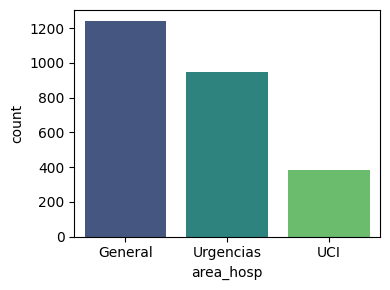

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(4,3))
sns.barplot(df['area_hosp'].value_counts(dropna=False), palette="viridis")
plt.tight_layout()
plt.savefig('../results/area_hosp_counts.png')

In [37]:
df['area_hosp'].value_counts()

area_hosp
General      1243
Urgencias     946
UCI           382
Name: count, dtype: int64

In [ ]:
df[df['microorganismo'].value_counts().head(15)

microorganismo
Escherichia coli              1154
Klebsiella pneumoniae          586
Staphylococcus aureus          528
Pseudomonas aeruginosa         363
Enterobacter cloacae           194
Klebsiella pneumoniae BLEE     158
Escherichia coli BLEE          121
Proteus mirabilis               95
Pseudomonas aeruginosa MR       92
Serratia marcescens             82
Klebsiella aerogenes            78
Klebsiella oxytoca              66
Staphylococcus aureus MR        51
Morganella morganii             41
Acinetobacter baumannii         38
Name: count, dtype: int64

In [96]:
urgencias= df[df['area_hosp']=='Urgencias']
urgencias.shape

(946, 65)

In [107]:
urgencias['microorganismo'].value_counts().sum()

np.int64(946)

In [110]:
urgencias['hemo_positivo_si_no'].value_counts()
df['hemo_positivo_si_no'].value_counts()

hemo_positivo_si_no
1    3891
Name: count, dtype: int64

In [101]:
import pandas as pd
import ast

# Example: your column
col = urgencias['microorganismo_episodios_previos']

# 1️⃣ Convert stringified dicts to real dicts
def str_to_dict(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return {}
    return x

col_dicts = col.apply(str_to_dict)

# 2️⃣ Count rows with at least one bacterium (not NaN)
non_empty_rows = col_dicts.apply(lambda d: any(pd.notna(v) for v in d.values())).sum()

# 3️⃣ Flatten all bacteria values and count occurrences
all_bacteria = [v for d in col_dicts for v in d.values() if pd.notna(v)]
bacteria_counts = pd.Series(all_bacteria).value_counts()

print("Previous infections records:", non_empty_rows)
print("Total bacteria occurrences:", len(all_bacteria))
print("\nTop bacteria:")
print(bacteria_counts.head(10))


Previous infections records: 37
Total bacteria occurrences: 185

Top bacteria:
Klebsiella pneumoniae ssp pneumoniae    68
Escherichia coli                        43
Pseudomonas aeruginosa                  23
Staphylococcus aureus ssp aureus        15
Proteus mirabilis                        9
Salmonella enterica.                     8
Citrobacter freundii                     4
Klebsiella oxytoca                       3
Morganella morganii ssp morganii         3
Staphylococcus aureus                    2
Name: count, dtype: int64


In [105]:
import numpy as np
import pandas as pd
from collections import Counter
import math
all_values = []
count_empty_episodes=0
urgencias_prev = urgencias['microorganismo_episodios_previos'].apply(str_to_dict)
for episode in urgencias_prev:
    for v in episode.values():
        if isinstance(v, str) and v.strip():  # keep only non-empty strings
            all_values.append(v)
        else:
            count_empty_episodes+=1

# Count occurrences
counts = Counter(all_values)

# Display neatly as a DataFrame
df_counts = pd.DataFrame(counts.items(), columns=["Bacterium", "Count"]).sort_values(by="Count", ascending=False)

print(df_counts)
print(f"Empty or non-string entries in previous episodes: {count_empty_episodes}")

                               Bacterium  Count
1   Klebsiella pneumoniae ssp pneumoniae     68
2                       Escherichia coli     43
0                 Pseudomonas aeruginosa     23
4       Staphylococcus aureus ssp aureus     15
3                      Proteus mirabilis      9
13                  Salmonella enterica.      8
8                   Citrobacter freundii      4
11                    Klebsiella oxytoca      3
6       Morganella morganii ssp morganii      3
5                  Staphylococcus aureus      2
9                Acinetobacter baumannii      2
12          Stenotrophomonas maltophilia      2
7       Enterobacter cloacae ssp cloacae      1
10                 Enterobacter asburiae      1
14                  Klebsiella aerogenes      1
Empty or non-string entries in previous episodes: 0


In [ ]:
# ['person_id', 'fecha_ingreso_urgencias', 'fecha_nacimiento', 'edad',
#        'sexo', 'codigo_postal', 'mujer_gestante', 'mayor_65',
#        'paciente_residencia', 'center', 'dag', 'inf_previa_sino',
#        'bmr_infec_previa', 'infarto', 'insuficiencia_cardiaca', 'evp',
#        'e_cerebrovascular', 'demencia', 'e_pulmonar_cronica',
#        'ulcera_peptica', 'colagenopatia', 'hemiplejia', 'erc',
#        'neoplasia', 'linfoma', 'leucemia', 'sida', 'hepatopatia',
#        'diabetes', 'indice_de_charlson', 'inmunosupresion',
#        'causa_inmunosupresion', 'situacion_funcional_basal',
#        'tipo_cancer_C00', 'tipo_cancer_C02', 'tipo_cancer_C10',
#        'tipo_cancer_C12', 'tipo_cancer_C13', 'tipo_cancer_C14',
#        'tipo_cancer_C15', 'tipo_cancer_C16', 'tipo_cancer_C17',
#        'tipo_cancer_C18', 'tipo_cancer_C19', 'tipo_cancer_C20',
#        'tipo_cancer_C21', 'tipo_cancer_C23', 'tipo_cancer_C24',
#        'tipo_cancer_C25', 'tipo_cancer_C26', 'tipo_cancer_C32',
#        'tipo_cancer_C33', 'tipo_cancer_C34', 'tipo_cancer_C37',
#        'tipo_cancer_C39', 'tipo_cancer_C40', 'tipo_cancer_C41',
#        'tipo_cancer_C43', 'tipo_cancer_C44', 'tipo_cancer_C45',
#        'tipo_cancer_C48', 'tipo_cancer_C49', 'tipo_cancer_C50',
#        'tipo_cancer_C51', 'tipo_cancer_C52', 'tipo_cancer_C53',
#        'tipo_cancer_C54', 'tipo_cancer_C55', 'tipo_cancer_C56',
#        'tipo_cancer_C57', 'tipo_cancer_C61', 'tipo_cancer_C62',
#        'tipo_cancer_C64', 'tipo_cancer_C65', 'tipo_cancer_C66',
#        'tipo_cancer_C67', 'tipo_cancer_C68', 'tipo_cancer_C70',
#        'tipo_cancer_C71', 'tipo_cancer_C73', 'tipo_cancer_C74',
#        'tipo_cancer_C7A', 'tipo_cancer_C81', 'tipo_cancer_C85',
#        'tipo_cancer_C90', 'tipo_cancer_D00', 'tipo_cancer_D03',
#        'tipo_cancer_D04', 'tipo_cancer_D05', 'tipo_cancer_D06',
#        'tipo_cancer_D07', 'tipo_cancer_D11', 'tipo_cancer_D12',
#        'tipo_cancer_D14', 'tipo_cancer_D17', 'tipo_cancer_D21',
#        'tipo_cancer_D24', 'tipo_cancer_D25', 'tipo_cancer_D27',
#        'tipo_cancer_D29', 'tipo_cancer_D31', 'tipo_cancer_D32',
#        'tipo_cancer_D33', 'tipo_cancer_D36', 'tipo_cancer_D3A',
#        'tipo_cancer_D42', 'tipo_cancer_D46', 'tipo_hepatopatia_B16',
#        'tipo_hepatopatia_B18', 'tipo_hepatopatia_B19',
#        'tipo_hepatopatia_K70', 'tipo_hepatopatia_K71',
#        'tipo_hepatopatia_K72', 'tipo_hepatopatia_K73',
#        'tipo_hepatopatia_K74', 'tipo_hepatopatia_K75',
#        'tipo_hepatopatia_K76', 'tipo_hepatopatia_K77',
#        'hospit_ano_previo', 'hospit_mes_previo', 'hospit_ano_previo_uci',
#        'cirugia_previa_sin_implant', 'cirugia_previa_con_implant',
#        'asistencia_sanitaria_prev', 'hemodialisis_permanente',
#        'dialisis_peritoneal', 'cateter_venoso', 'sonda_urinaria',
#        'sonda_nasogastrica', 'derivacion_ventriculoper',
#        'valvula_prot_cardiaca', 'portador_otros_disposit', 'foco',
#        'sepsis', 'shock_septico', 'sofa', 'respiracion', 'snc_glasgow',
#        'cardiovascular', 'bilirrubina', 'plaquetas', 'creatinina',
#        'lactato_serico', 'vasopresores', 'proteina_c_reactiva', 'qsofa',
#        'estado_mental_alterado', 'proteina_c_reactiva_recoded',
#        'temperatura', 'hipotermia_hipertermia', 'frec_cardiaca',
#        'taquicardia', 'frec_respiratoria', 'taquipnea',
#        'tension_arterial', 'hipotension', 'saturacion_o2', 'hipoxemia',
#        'temperatura_recoded', 'frec_respiratoria_recoded',
#        'frec_cardiaca_recoded', 'tension_arterial_recoded',
#        'saturacion_o2_recoded', 'sintoma_1.0', 'sintoma_10.0',
#        'sintoma_11.0', 'sintoma_12.0', 'sintoma_13.0', 'sintoma_14.0',
#        'sintoma_15.0', 'sintoma_16.0', 'sintoma_2.0', 'sintoma_3.0',
#        'sintoma_4.0', 'sintoma_5.0', 'sintoma_6.0', 'sintoma_7.0',
#        'sintoma_8.0', 'sintoma_9.0', 'sintoma_nan',
#        'sintoma_1.0_categorico', 'sintoma_10.0_categorico',
#        'sintoma_11.0_categorico', 'sintoma_12.0_categorico',
#        'sintoma_13.0_categorico', 'sintoma_14.0_categorico',
#        'sintoma_15.0_categorico', 'sintoma_16.0_categorico',
#        'sintoma_2.0_categorico', 'sintoma_3.0_categorico',
#        'sintoma_4.0_categorico', 'sintoma_5.0_categorico',
#        'sintoma_6.0_categorico', 'sintoma_7.0_categorico',
#        'sintoma_8.0_categorico', 'sintoma_9.0_categorico',
#        'sintoma_nan_categorico']

array(['fecha_ingreso', 'fecha_alta', 'duracion_hospitalizacion',
       'fecha_nacimiento', 'edad', 'sexo', 'codigo_postal',
       'mujer_gestante', 'infarto', 'insuficiencia_cardiaca', 'evp',
       'e_cerebrovascular', 'demencia', 'e_pulmonar_cronica',
       'ulcera_peptica', 'colagenopatia', 'hemiplejia', 'erc',
       'neoplasia_tratamiento_activo', 'neoplasia_solida_metastasica',
       'neoplasia_solida_no_metastasica', 'tipo_cancer', 'linfoma',
       'leucemia', 'sida', 'tipo_hepatopatia', 'diabetes',
       'diabetes_sin_lesion_organo_diana',
       'diabetes_con_lesion_organo_diana', 'inmunosupresion',
       'causa_inmunosupresion', 'TOS', 'TPH', 'clasificacion_quemadura',
       'gran_quemado', 'sepsis', 'shock_septico', 'hospit_ano_previo',
       'hospit_mes_previo', 'hospit_ano_previo_uci',
       'hemodialisis_permanente', 'dialisis_peritoneal', 'cateter_venoso',
       'sonda_urinaria', 'sonda_nasogastrica', 'derivacion_ventriculoper',
       'valvula_prot_cardiaca'

In [24]:
## codes2names
codes2names = pd.read_csv(codes2names_file, index_col=0)
codes2names['Descripcion'] = codes2names['Descripcion'].str.replace('[', '').str.replace(']', '')
codes2names.head()

,Variable,Descripcion,Formato,Lista_origen,Unnamed: 5
Form,,,,,
caso,Record ID,record_id,Autocalculado,NaN,NaN
caso,Fecha de ingreso,fecha_ingreso,Fecha,NaN,NaN
caso,Fecha de nacimiento,fecha_nacimiento,Fecha,NaN,NaN
caso,Edad,edad,Autocalculado,formula_edad_al_ingreso,"rounddown(datediff([fecha_nacimiento],[fecha_i..."
caso,Sexo,sexo,Hombre/Mujer,NaN,NaN


In [34]:
common = set(df.columns) & set(codes2names['Descripcion'].values)
print(f"{len(df.columns)}/{codes2names.shape[0]}) columns in common")
print(f"Common columns: {len(common)}")

119/133) columns in common
Common columns: 47


In [32]:
print(df.columns.values)

['fecha_ingreso' 'fecha_alta' 'duracion_hospitalizacion'
 'fecha_nacimiento' 'edad' 'sexo' 'codigo_postal' 'mujer_gestante'
 'infarto' 'insuficiencia_cardiaca' 'evp' 'e_cerebrovascular' 'demencia'
 'e_pulmonar_cronica' 'ulcera_peptica' 'colagenopatia' 'hemiplejia' 'erc'
 'neoplasia_tratamiento_activo' 'neoplasia_solida_metastasica'
 'neoplasia_solida_no_metastasica' 'tipo_cancer' 'linfoma' 'leucemia'
 'sida' 'tipo_hepatopatia' 'diabetes' 'diabetes_sin_lesion_organo_diana'
 'diabetes_con_lesion_organo_diana' 'inmunosupresion'
 'causa_inmunosupresion' 'TOS' 'TPH' 'clasificacion_quemadura'
 'gran_quemado' 'sepsis' 'shock_septico' 'hospit_ano_previo'
 'hospit_mes_previo' 'hospit_ano_previo_uci' 'hemodialisis_permanente'
 'dialisis_peritoneal' 'cateter_venoso' 'sonda_urinaria'
 'sonda_nasogastrica' 'derivacion_ventriculoper' 'valvula_prot_cardiaca'
 'portador_otros_disposit' 'fecha_episodio_previo_1' 'especimen_previo_1'
 'cultivo_previo_1' 'microorganism_episodio_previo_1'
 'resultado_anti